# Monitoring ice velocity on Vega Island, Antarctica, using Sentinel-1 offset tracking

## Author: Moritz Rath

Geoprocessing with Python, Wintersemester 25/26, Geographisches Institut, Humboldt-Universität zu Berlin
Supervisors: Dr. Dirk Pflugmacher, Eduardo Ribeiro Lacerda

Hand-in due: April 15, 2026

**1. Import Packages**

In [12]:
import os
import ee
import geemap
import json
import geopandas as gpd
import numpy as np
from rasterio.plot import show
from matplotlib import pyplot as plt
from multiprocessing import get_context, cpu_count

import FCK_ICE_fun as fun

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

path = 'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data'

Import region shapefile for Vega Island

In [2]:
regionSHP = gpd.read_file(os.path.join(path, 'geodata/vega_island.shp'))
regionSHP = regionSHP.to_crs(epsg=4326)
regionSHP = regionSHP.drop(columns=['sourcedate', 'revdate'])
regionJS = regionSHP.to_json()
#regionJS = json.loads(regionSHP.to_json())
region = ee.FeatureCollection(json.loads(regionJS))
#region_buff_out = region.geometry().buffer(500)
#region_poly = region_buff_out.buffer(-500)

In [9]:
Map = geemap.Map()
Map.centerObject(region, 10)
Map.addLayer(region, {}, 'Region')
Map.addLayer(lo_fc, {}, 'Glaciers')
#Map.addLayer(glaciermask, {}, 'Glacier Mask')
Map

Map(center=[-63.84266356378092, -57.40258782887183], controls=(WidgetControl(options=['position', 'transparent…

Get data from GEE

In [14]:
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD') \
      .filterBounds(region) \
      .filterDate('2020-01-01', '2025-01-01') \
      .filter(ee.Filter.eq('instrumentMode', 'IW')) \
      .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')) \
      .select('HH') \
      .map(lambda img: img.set(
          'acq_date',
          ee.String(ee.String(img.get('system:index')).split('_').get(4)).slice(0, 8)
      )) \
      .sort('acq_date'))

s1

In [ ]:
kwargs = {
    'grid_res': 200,
    'window_size': (256, 256),
    'path_out': 'auto',
    'fmt_out': 'GTIFF',
    'projectDir': 'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister',
    'q' : True,
}

In [5]:
fun.coregisterS1(s1=s1, region=region, kwargs=kwargs)

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200104.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200110.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200110.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200116.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200116.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200122.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200122.tif
Generating URL ...
Please 

c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\Tie_Point_Grid.py:1167: UserWarning: RANSAC filtering could not be applied because there were too few tie points to fit a model.
  warn('RANSAC filtering could not be applied '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200427.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200503.tif
Calculating tie point grid (128 points) using 8 CPU cores...
RANSAC skipped because too less valid tie points have been found.


c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\DeShifter.py:167: UserWarning: Only 3 valid tie point(s) could be identified. A local shift correction is therefore not reasonable and could cause artifacts in the output image. The target image is corrected globally with the mean X/Y shift of -0.174/0.121 pixels.
  warnings.warn(f'Only {len(self.GCPList)} valid tie point(s) could be identified. A local shift correction '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200503.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200509.tif
Calculating tie point grid (153 points) using 8 CPU cores...
RANSAC skipped because too less valid tie points have been found.


...

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221201.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221213.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221213.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221225.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221225.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20230106.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20230106.tif
Generating URL ...
Please 

c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\Tie_Point_Grid.py:1167: UserWarning: RANSAC filtering could not be applied because there were too few tie points to fit a model.
  warn('RANSAC filtering could not be applied '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240524.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240605.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240605.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240617.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240617.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240629.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240629.tif
Generating URL ...
Please 

c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\DeShifter.py:167: UserWarning: Only 2 valid tie point(s) could be identified. A local shift correction is therefore not reasonable and could cause artifacts in the output image. The target image is corrected globally with the mean X/Y shift of 0.213/0.270 pixels.
  warnings.warn(f'Only {len(self.GCPList)} valid tie point(s) could be identified. A local shift correction '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240828.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240909.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240909.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240921.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240921.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20241003.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20241003.tif
Generating URL ...
Please 

In [ ]:
demCOL = (ee.ImageCollection("UMN/PGC/REMA/V1/2m")\
          .filterBounds(region))
dem_mosaic = demCOL.reduce(ee.Reducer.min())
dem_mosaic = dem_mosaic.clip(region)

In [11]:
regionEx = ee.FeatureCollection(region).geometry()
regionEx = regionEx.transform('EPSG:4326', maxError=1)
geemap.ee_export_image(dem_mosaic, filename=os.path.join(path, "geodata/dem.tif"), 
                       scale=90, region=regionEx, file_per_band=False)

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\Documents\Uni\HU\Python\geopy_final\data\geodata\dem.tif


Retrieve the glacier mask maximum extent. We pin movement to this area to exclude movement in bedrock around the glaciers. 

In [10]:
rgi = ee.FeatureCollection("GLIMS/20230607") \
        .filterBounds(region)
gl = rgi.geometry().simplify(maxError=1)
glaciermask = gl.dissolve()
parts = ee.List(glaciermask.geometries())
fc_parts = ee.FeatureCollection(
    parts.map(lambda g:  ee.Feature(ee.Geometry(g)).set("area_m2", ee.Geometry(g).area(1)))
)

me = ee.Feature(fc_parts.sort("area_m2", False).first())
me_fc =ee.FeatureCollection([me])

out_shp = os.path.join(path, "geodata", "glacier_max_extent.shp")
geemap.ee_export_vector(me_fc, filename=out_shp)

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\Documents\Uni\HU\Python\geopy_final\data\geodata\glacier_max_extent.shp


In [3]:
gm = gpd.read_file(os.path.join(path, "geodata", "glacier_max_extent.shp"))

# Rename the coregistered Images

In [2]:
path_coregister = r'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister'
fun.renameTifs(path_coregister, move=False, recursive=True)

Source folder: C:\Users\morit\Documents\Uni\HU\Python\geopy_final\data\coregister
Found tif/tiff files: 208
Matched rename pattern: 208
Written files: 208 to C:\Users\morit\Documents\Uni\HU\Python\geopy_final\data\coregister_coregistered


[(WindowsPath('C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister/20200104__shifted_to__20200110.tif'),
  WindowsPath('C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister_coregistered/20200107_coregistered.tif')),
 (WindowsPath('C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister/20200110__shifted_to__20200116.tif'),
  WindowsPath('C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister_coregistered/20200113_coregistered.tif')),
 (WindowsPath('C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister/20200116__shifted_to__20200122.tif'),
  WindowsPath('C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister_coregistered/20200119_coregistered.tif')),
 (WindowsPath('C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister/20200122__shifted_to__20200128.tif'),
  WindowsPath('C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister_coregistered/20200125_coregistered.tif')),
 (WindowsPath('C:/Us

Load Tifs

In [4]:
path_coregister2 = r'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister_coregistered'
tiflist = fun.loadTifs(path_coregister2)
masked_tifs, template = fun.maskTif_loop(tiflist, regionSHP, gm, crop=False)

In [6]:
print([a.shape for a in masked_tifs])

[(1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 3219), (1, 1649, 321

Create monthly means

In [9]:
stack = np.stack(masked_tifs, axis=0)
stack = np.where(stack == 0, np.nan, stack)

In [ ]:
mean_array = np.nanmean(stack, axis=0)

C:\Users\morit\AppData\Local\Temp\ipykernel_1844\3613035901.py:1: RuntimeWarning: Mean of empty slice
  mean_array = np.nanmean(stack, axis=0)


In [ ]:
mean_array = np.squeeze(mean_array)

In [ ]:
mean_fixed = np.abs(mean_array)

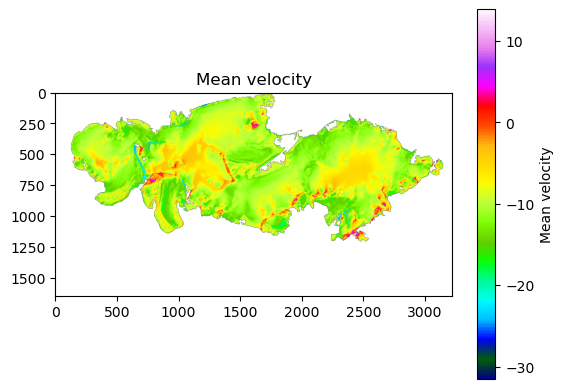

In [17]:
plt.imshow(mean_array, cmap="gist_ncar")
plt.colorbar(label="Mean velocity")
plt.title("Mean velocity")
plt.show()